In [1]:
from pathlib import Path
import importlib.util
import sys

module_candidates = [
    Path.cwd() / 'generate_lab7.py',
    Path.cwd() / 'lab7' / 'generate_lab7.py',
]
module_path = next(path for path in module_candidates if path.exists())
spec = importlib.util.spec_from_file_location('generate_lab7', module_path)
lab7 = importlib.util.module_from_spec(spec)
sys.modules['generate_lab7'] = lab7
spec.loader.exec_module(lab7)

summary = lab7.run_pipeline()
summary

{'variant': 17,
 'alphabet_name': 'Казахские строчные буквы',
 'phrase': 'сәулем мен сені сүйемін',
 'font_name': 'Arial',
 'font_size': 52,
 'experiment_font_size': 58,
 'feature_weights': 'mass=0.1, centroid_x=1, centroid_y=1, inertia_h=2, inertia_v=2',
 'main_recognized': 'сәулем меи сеиі сүйеміи',
 'main_errors': 3,
 'main_accuracy_percent': 85.0,
 'experiment_recognized': 'сәулем мен сені сүйемін',
 'experiment_errors': 0,
 'experiment_accuracy_percent': 100.0,
 'summary_path': 'C:\\Users\\User\\vs\\oavi\\lab7\\summary_variant17.csv',
 'main_hypotheses_path': 'C:\\Users\\User\\vs\\oavi\\lab7\\hypotheses_variant17.txt',
 'experiment_hypotheses_path': 'C:\\Users\\User\\vs\\oavi\\lab7\\hypotheses_variant17_font58.txt'}

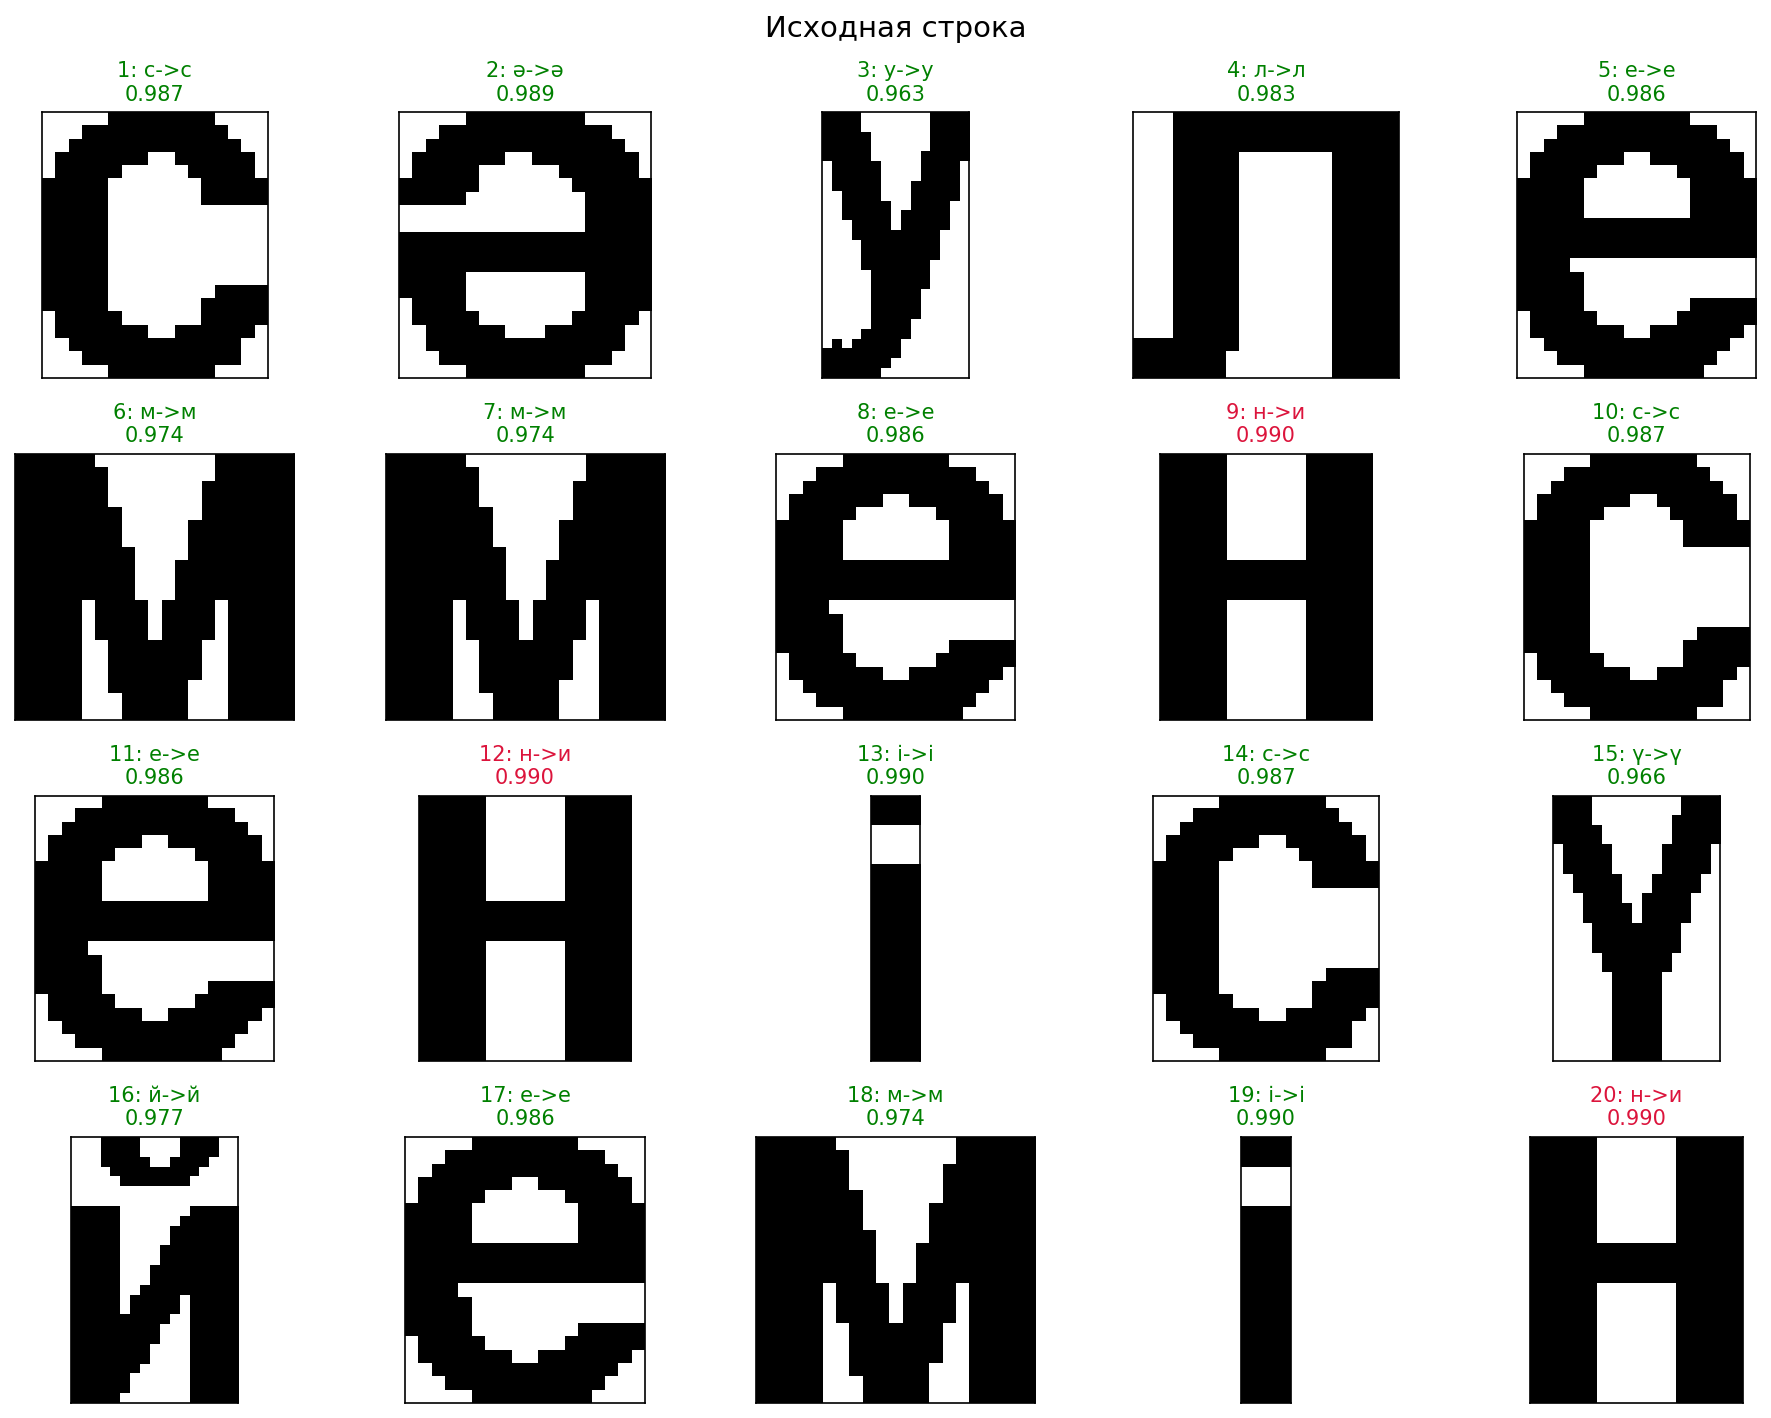

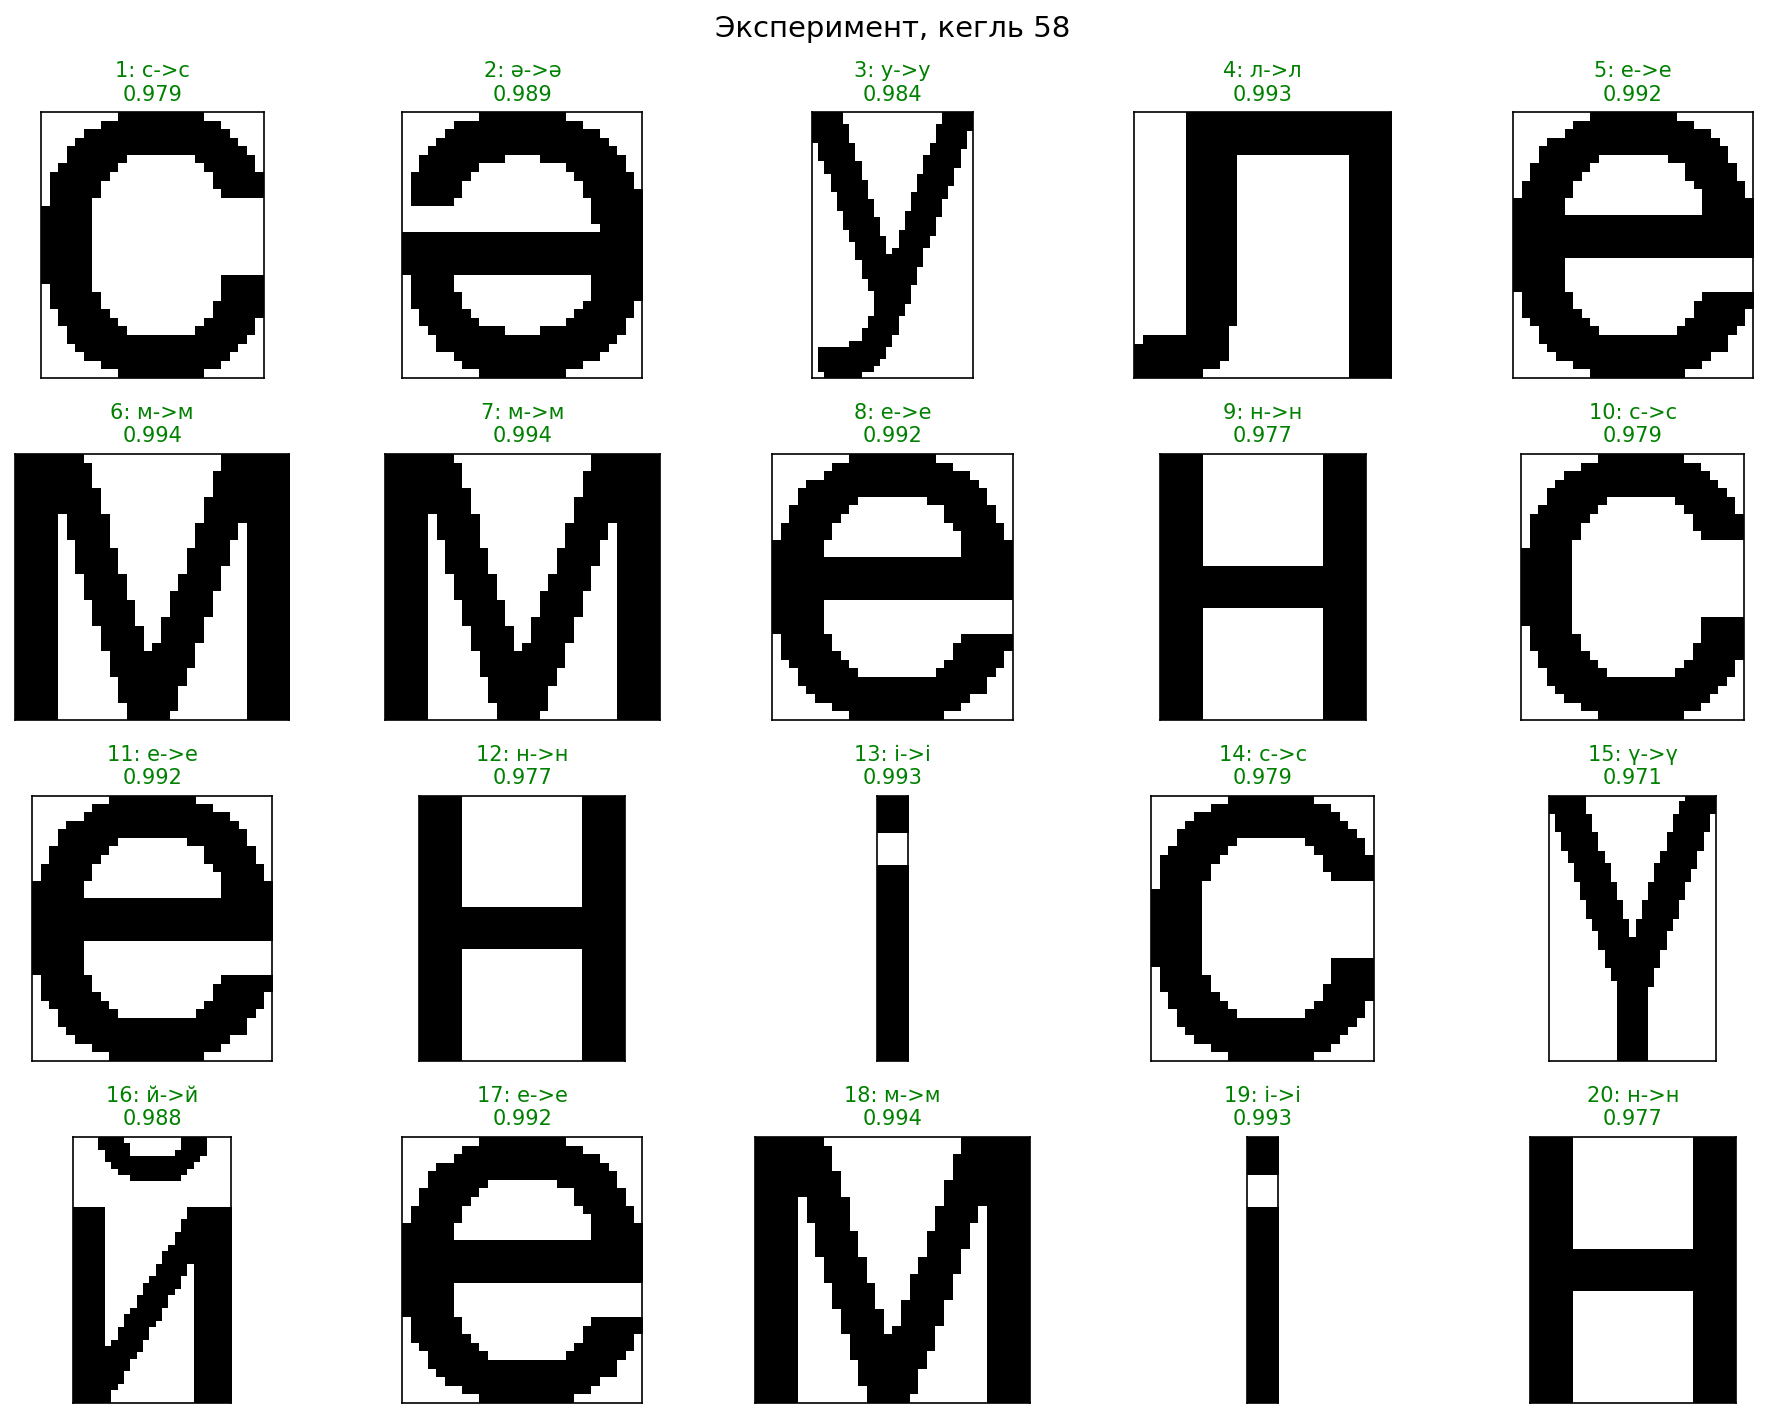

In [2]:
from IPython.display import Image, display

base = module_path.parent
display(Image(filename=str(base / 'preview_png' / 'classification_main.png')))
display(Image(filename=str(base / 'preview_png' / 'classification_experiment_font58.png')))

In [3]:
for path in [base / 'hypotheses_variant17.txt', base / 'hypotheses_variant17_font58.txt']:
    print(path.name)
    lines = path.read_text(encoding='utf-8').splitlines()
    for line in lines[:3]:
        print(line)
    print()

hypotheses_variant17.txt
1: [('с', 0.9873), ('в', 0.9710), ('б', 0.9519), ('ю', 0.9500), ('к', 0.9434), ('е', 0.9431), ('о', 0.9324), ('ж', 0.9229), ('ә', 0.9228), ('ө', 0.9215), ('м', 0.9165), ('а', 0.9152), ('ё', 0.9148), ('х', 0.9139), ('қ', 0.9133), ('у', 0.9114), ('д', 0.9082), ('ш', 0.9050), ('ъ', 0.9050), ('ұ', 0.9030), ('и', 0.9026), ('щ', 0.9018), ('і', 0.8994), ('э', 0.8971), ('р', 0.8967), ('ц', 0.8952), ('й', 0.8950), ('һ', 0.8896), ('ы', 0.8885), ('л', 0.8884), ('ф', 0.8867), ('я', 0.8847), ('з', 0.8800), ('н', 0.8789), ('ү', 0.8784), ('п', 0.8782), ('ь', 0.8722), ('ғ', 0.8712), ('ң', 0.8647), ('т', 0.8412), ('ч', 0.8358), ('г', 0.8231)]
2: [('ә', 0.9887), ('ө', 0.9832), ('д', 0.9729), ('о', 0.9726), ('а', 0.9709), ('е', 0.9649), ('э', 0.9584), ('б', 0.9556), ('ж', 0.9508), ('я', 0.9457), ('ю', 0.9444), ('м', 0.9437), ('в', 0.9381), ('л', 0.9352), ('з', 0.9350), ('щ', 0.9347), ('ё', 0.9336), ('ц', 0.9329), ('х', 0.9290), ('ұ', 0.9276), ('и', 0.9237), ('ф', 0.9209), ('і', 0

In [4]:
import csv

for path in [base / 'summary_variant17.csv', base / 'classification_main.csv', base / 'classification_experiment_font58.csv']:
    print(path.name)
    with path.open('r', encoding='utf-8-sig', newline='') as f:
        reader = csv.reader(f, delimiter=';')
        for i, row in enumerate(reader):
            print(row)
            if i == 5:
                break
    print()

summary_variant17.csv
['mode', 'expected', 'recognized', 'recognized_with_spaces', 'errors', 'accuracy_percent', 'hypotheses_path', 'csv_path']
['Исходная строка', 'сәулемменсенісүйемін', 'сәулеммеисеиісүйеміи', 'сәулем меи сеиі сүйеміи', '3', '85.0', 'hypotheses_variant17.txt', 'classification_main.csv']
['Эксперимент, кегль 58', 'сәулемменсенісүйемін', 'сәулемменсенісүйемін', 'сәулем мен сені сүйемін', '0', '100.0', 'hypotheses_variant17_font58.txt', 'classification_experiment_font58.csv']

classification_main.csv
['index', 'expected', 'recognized', 'best_similarity', 'is_correct', 'top1_symbol', 'top1_similarity', 'top2_symbol', 'top2_similarity', 'top3_symbol', 'top3_similarity', 'top4_symbol', 'top4_similarity', 'top5_symbol', 'top5_similarity']
['1', 'с', 'с', '0.987279', '1', 'с', '0.987279', 'в', '0.970954', 'б', '0.951856', 'ю', '0.950048', 'к', '0.943442']
['2', 'ә', 'ә', '0.988672', '1', 'ә', '0.988672', 'ө', '0.983174', 'д', '0.972878', 'о', '0.972601', 'а', '0.970871']
['3